In [1]:
!pip install timm --quiet

In [2]:
import os
import numpy as np
import pandas as pd
from PIL import Image
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import timm

from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             confusion_matrix, classification_report)
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

Using device: cuda


In [3]:
DATASET_PATH = "/kaggle/input/datasets/jimmy98/faceforensics-celebv1-and-v2-df-combined-dataset/1000_videos"

splits     = ['train', 'validation', 'test']
extensions = ['.jpg', '.jpeg', '.png']

all_paths  = []
all_labels = []
all_splits = []

for split in splits:
    for label_name, label_val in [('real', 0), ('fake', 1)]:
        folder = Path(DATASET_PATH) / split / label_name
        if not folder.exists():
            print(f"WARNING: Not found — {folder}")
            continue
        images = [f for f in folder.iterdir() if f.suffix.lower() in extensions]
        print(f"{split}/{label_name} : {len(images)} images")
        all_paths.extend([str(f) for f in images])
        all_labels.extend([label_val] * len(images))
        all_splits.extend([split] * len(images))

df = pd.DataFrame({'path': all_paths, 'label': all_labels, 'split': all_splits})
print(f"\nTotal images : {len(df)}")
print(df['label'].value_counts())

train/real : 5605 images
train/fake : 6028 images
validation/real : 1200 images
validation/fake : 1200 images
test/real : 1200 images
test/fake : 1200 images

Total images : 16433
label
1    8428
0    8005
Name: count, dtype: int64


In [4]:
train_df = df[df['split'] == 'train'].reset_index(drop=True)
val_df   = df[df['split'] == 'validation'].reset_index(drop=True)
test_df  = df[df['split'] == 'test'].reset_index(drop=True)

print(f"Train : {len(train_df)}  (Real: {(train_df.label==0).sum()}, Fake: {(train_df.label==1).sum()})")
print(f"Val   : {len(val_df)}  (Real: {(val_df.label==0).sum()}, Fake: {(val_df.label==1).sum()})")
print(f"Test  : {len(test_df)}  (Real: {(test_df.label==0).sum()}, Fake: {(test_df.label==1).sum()})")

Train : 11633  (Real: 5605, Fake: 6028)
Val   : 2400  (Real: 1200, Fake: 1200)
Test  : 2400  (Real: 1200, Fake: 1200)


In [5]:
class DeepfakeDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        path  = self.df.loc[idx, 'path']
        label = self.df.loc[idx, 'label']
        image = Image.open(path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.long)


train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

train_dataset = DeepfakeDataset(train_df, transform=train_transform)
val_dataset   = DeepfakeDataset(val_df,   transform=val_transform)
test_dataset  = DeepfakeDataset(test_df,  transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False,
                          num_workers=2, pin_memory=True)

print("Dataloaders ready")

Dataloaders ready


In [6]:
model = timm.create_model('efficientnet_b4', pretrained=True, num_classes=2)
model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Model loaded successfully")
print(f"Total parameters: {total_params:,}")

model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

Model loaded successfully
Total parameters: 17,552,202


In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=15)

EPOCHS       = 15
best_val_acc = 0.0

train_losses, val_losses, val_accuracies = [], [], []

In [8]:
for epoch in range(EPOCHS):

    # ---- Train phase ----
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # ---- Validation phase ----
    model.eval()
    val_loss       = 0.0
    all_preds      = []
    all_labels_val = []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss    = criterion(outputs, labels)
            val_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels_val.extend(labels.cpu().numpy())

    avg_val_loss = val_loss / len(val_loader)
    val_acc      = accuracy_score(all_labels_val, all_preds)

    val_losses.append(avg_val_loss)
    val_accuracies.append(val_acc)
    scheduler.step()

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_model.pth')

    print(f"Epoch [{epoch+1:2d}/{EPOCHS}]  "
          f"Train Loss: {avg_train_loss:.4f}  "
          f"Val Loss: {avg_val_loss:.4f}  "
          f"Val Accuracy: {val_acc*100:.2f}%")

print(f"\nBest Validation Accuracy: {best_val_acc*100:.2f}%")
print("Model saved as best_model.pth")

Epoch [ 1/15]  Train Loss: 0.6220  Val Loss: 0.4586  Val Accuracy: 79.08%
Epoch [ 2/15]  Train Loss: 0.2650  Val Loss: 0.3390  Val Accuracy: 86.92%
Epoch [ 3/15]  Train Loss: 0.1618  Val Loss: 0.3068  Val Accuracy: 88.12%
Epoch [ 4/15]  Train Loss: 0.1172  Val Loss: 0.2689  Val Accuracy: 90.21%
Epoch [ 5/15]  Train Loss: 0.0889  Val Loss: 0.2595  Val Accuracy: 90.79%
Epoch [ 6/15]  Train Loss: 0.0697  Val Loss: 0.2659  Val Accuracy: 91.04%
Epoch [ 7/15]  Train Loss: 0.0559  Val Loss: 0.2584  Val Accuracy: 91.67%
Epoch [ 8/15]  Train Loss: 0.0510  Val Loss: 0.2358  Val Accuracy: 92.38%
Epoch [ 9/15]  Train Loss: 0.0413  Val Loss: 0.2797  Val Accuracy: 91.54%
Epoch [10/15]  Train Loss: 0.0408  Val Loss: 0.2398  Val Accuracy: 92.50%
Epoch [11/15]  Train Loss: 0.0324  Val Loss: 0.2435  Val Accuracy: 92.50%
Epoch [12/15]  Train Loss: 0.0334  Val Loss: 0.2620  Val Accuracy: 92.29%
Epoch [13/15]  Train Loss: 0.0280  Val Loss: 0.2421  Val Accuracy: 92.50%
Epoch [14/15]  Train Loss: 0.0295  Val

In [9]:
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

all_preds       = []
all_labels_test = []
all_probs       = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs   = torch.softmax(outputs, dim=1)[:, 1]
        preds   = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels_test.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

accuracy = accuracy_score(all_labels_test, all_preds)
f1       = f1_score(all_labels_test, all_preds)
auc      = roc_auc_score(all_labels_test, all_probs)
cm       = confusion_matrix(all_labels_test, all_preds)

print("=" * 45)
print("          FINAL TEST RESULTS")
print("=" * 45)
print(f"  Accuracy  :  {accuracy*100:.2f}%")
print(f"  F1 Score  :  {f1:.4f}")
print(f"  AUC-ROC   :  {auc:.4f}")
print("=" * 45)
print()
print(classification_report(all_labels_test, all_preds,
                             target_names=['Real', 'Fake']))
print("Confusion Matrix:")
print(cm)
print()
print(f"  Fakes correctly caught  : {cm[1][1]}")
print(f"  Fakes missed            : {cm[1][0]}")
print(f"  Real wrongly flagged    : {cm[0][1]}")
print(f"  Real correctly passed   : {cm[0][0]}")

          FINAL TEST RESULTS
  Accuracy  :  89.42%
  F1 Score  :  0.8882
  AUC-ROC   :  0.9684

              precision    recall  f1-score   support

        Real       0.86      0.95      0.90      1200
        Fake       0.94      0.84      0.89      1200

    accuracy                           0.89      2400
   macro avg       0.90      0.89      0.89      2400
weighted avg       0.90      0.89      0.89      2400

Confusion Matrix:
[[1137   63]
 [ 191 1009]]

  Fakes correctly caught  : 1009
  Fakes missed            : 191
  Real wrongly flagged    : 63
  Real correctly passed   : 1137


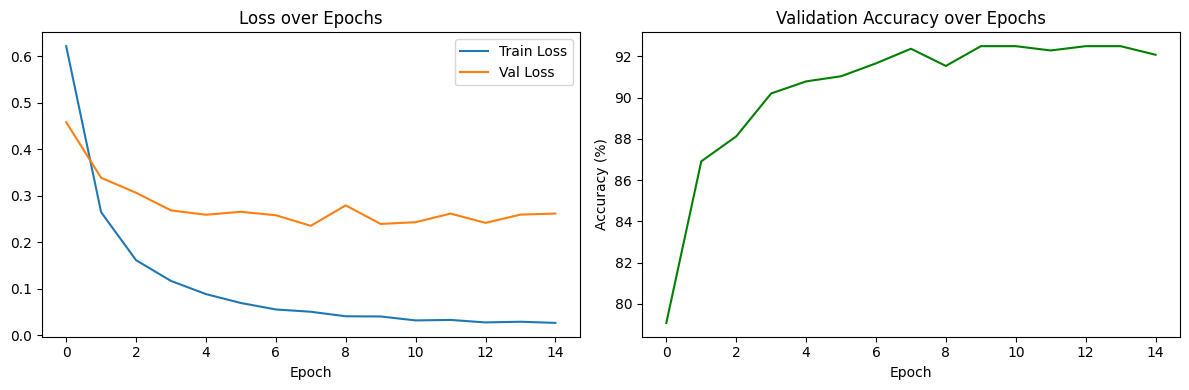

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses, label='Train Loss')
ax1.plot(val_losses,   label='Val Loss')
ax1.set_title('Loss over Epochs')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot([v * 100 for v in val_accuracies], color='green')
ax2.set_title('Validation Accuracy over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')

plt.tight_layout()
plt.savefig('training_curves.png')
plt.show()